# PPR Fantasy Points Regression Using Sentiment Indices

While much of our analysis has focused on determining correlations between sentiment indices and performance metrics, it is unclear if sentiment indices can predict the next week's performance. This is an investigation into the above hypothesis that sentiment indices are useful for predicting athletic performance (in this case, PPR fantasy points)

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, cross_val_score, PredefinedSplit
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import scipy.stats as stats

## EDA

In [2]:
# Read in data
twitter_df = pd.read_csv('sentiment_indices/twitter_local_index_sprint2.csv')
global_df = pd.read_csv('sentiment_indices/global_index.csv')
perf_df = pd.read_csv('data/nfl_sentiment_2025_cleaned.csv')

# Filter to appropriate columns
perf_df = perf_df[['player_name', 'player_position', 'game_week', 'fantasy_points_ppr', 'opp_defense_dvoa']]

# Join sentiment data frames together
sent_df = pd.merge(twitter_df, global_df, left_on=['subject', 'game_id'], right_on=['player', 'week'])
sent_df = sent_df[['player', 'week', 'local_index', 'global_index']]

# Make corrections to data types/player names as necessary
sent_df['player'] = sent_df['player'].replace({'AJ Brown': 'A.J. Brown',
                                               'JaMarr Chase': 'Ja\'Marr Chase',
                                               'Greg Rousseau': 'Gregory Rousseau',
                                               'Michael Pittman Jr': 'Michael Pittman',
                                               'Antoine Winfield Jr': 'Antoine Winfield Jr.'})
sent_df['week'] = sent_df.apply(
    lambda x: int(x['week'][1:]), axis=1
)

# Join sentiment and performance indices together
df = pd.merge(perf_df, sent_df, left_on=['player_name', 'game_week'], right_on=['player', 'week'])
df = df[['player', 'fantasy_points_ppr', 'player_position', 'week', 'opp_defense_dvoa', 'local_index', 'global_index']]
df = df.rename(columns={'local_index': 'twitter_index'})
df.head()

,player,fantasy_points_ppr,player_position,week,opp_defense_dvoa,twitter_index,global_index
0,Dak Prescott,7.82,QB,1,-9.9,45.722312,54.586238
1,Saquon Barkley,18.40,RB,1,22.5,64.864458,64.850791
2,A.J. Brown,1.80,WR,1,22.5,39.802578,52.085014
3,CeeDee Lamb,18.00,WR,1,-9.9,50.161475,56.322198
4,Zack Baun,0.00,ILB,1,22.5,65.895185,64.885360


In [3]:
off_df = df[df['player_position'].isin(['QB', 'RB', 'WR', 'TE'])]
off_df['prev_fantasy_pts'] = off_df.groupby('player')['fantasy_points_ppr'].shift(1)
off_df['prev_twitter_index'] = off_df.groupby('player')['twitter_index'].shift(1)
off_df['prev_global_index'] = off_df.groupby('player')['global_index'].shift(1)
off_df = off_df.drop(columns={'twitter_index', 'global_index'})
off_df = off_df.dropna()

/tmp/ipykernel_40404/2844722803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  off_df['prev_fantasy_pts'] = off_df.groupby('player')['fantasy_points_ppr'].shift(1)
/tmp/ipykernel_40404/2844722803.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  off_df['prev_twitter_index'] = off_df.groupby('player')['twitter_index'].shift(1)
/tmp/ipykernel_40404/2844722803.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

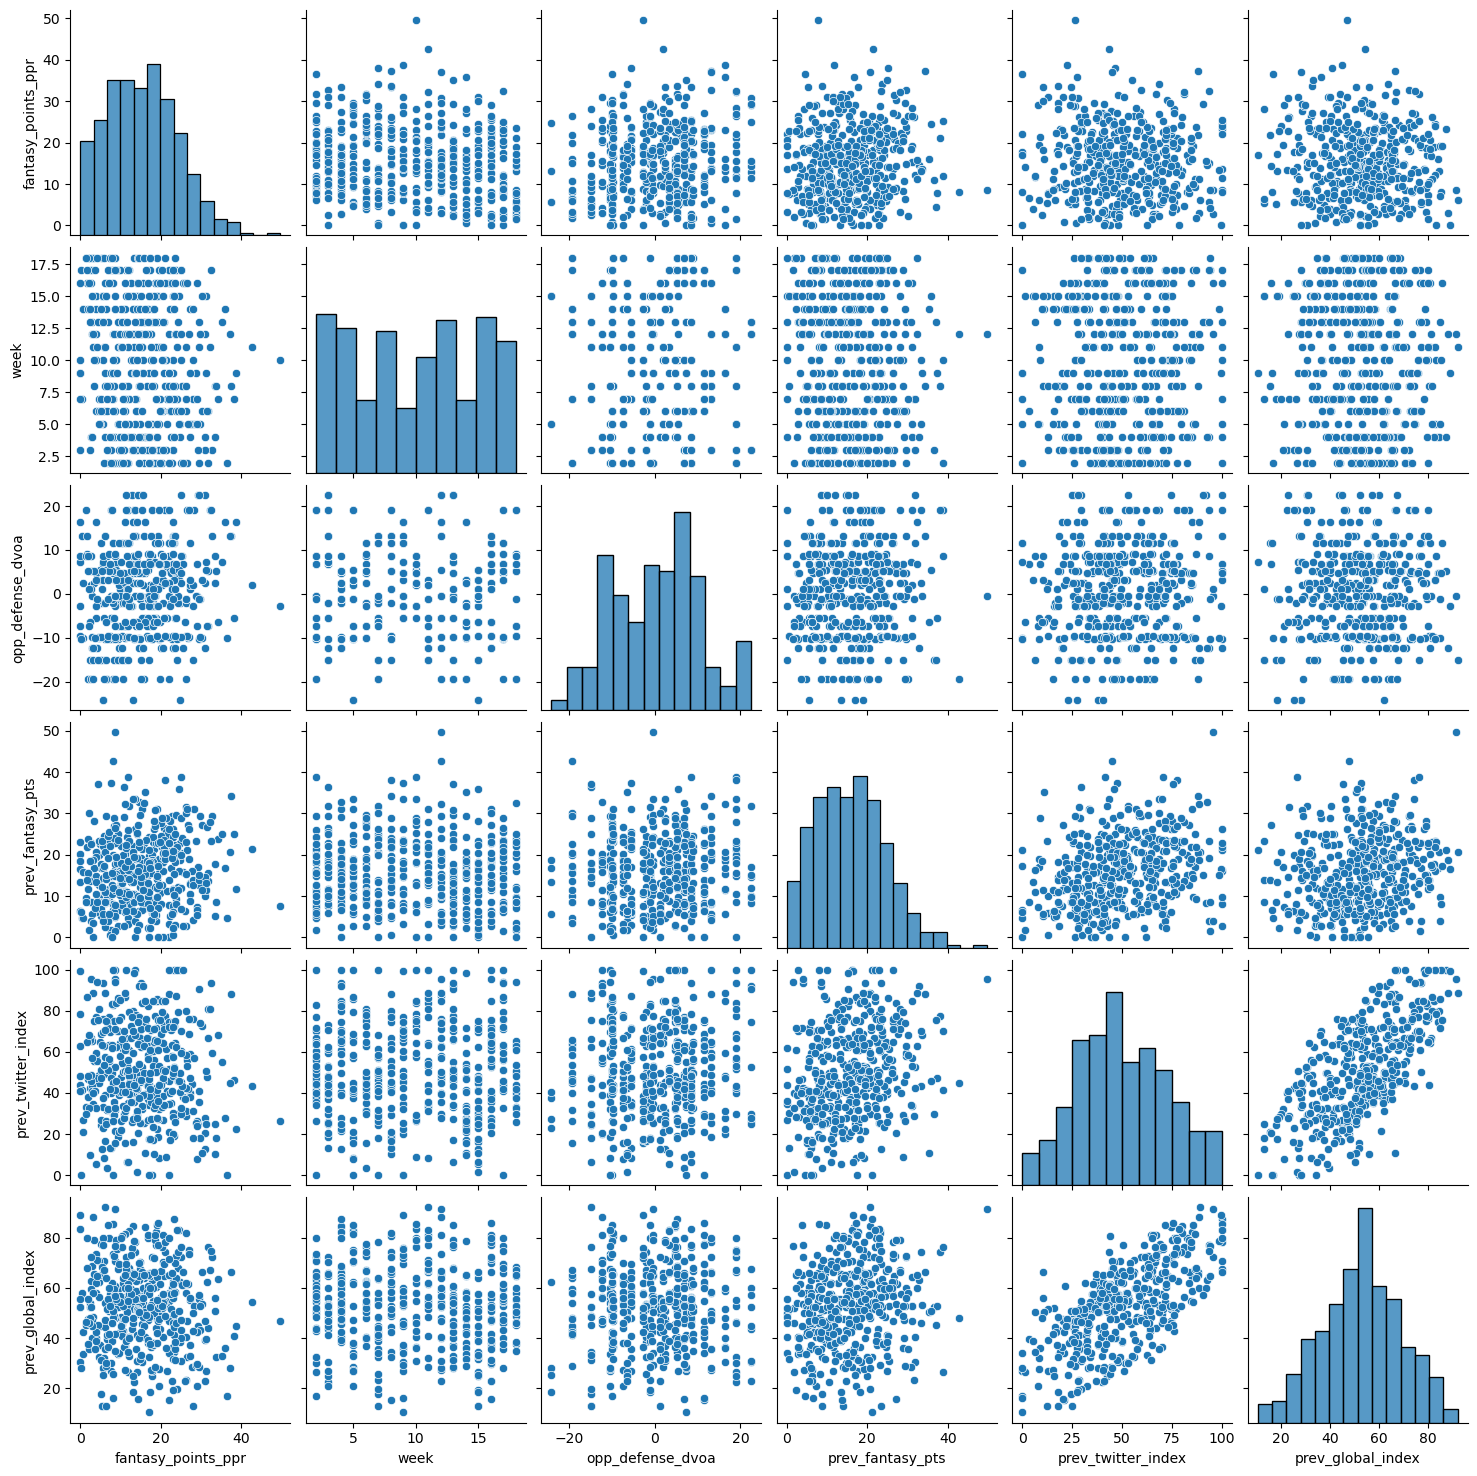

In [4]:
sns.pairplot(off_df.drop('player', axis=1))
plt.show()

No evidence to make and transformations or use relationships other than linear for the first go around

No collinearity with other predictors either

# One-Hot Encode Position

In [5]:
off_df = pd.concat([off_df, pd.get_dummies(off_df['player_position'])], axis=1)
off_df.head()

,player,fantasy_points_ppr,player_position,week,opp_defense_dvoa,prev_fantasy_pts,prev_twitter_index,prev_global_index,QB,RB,TE,WR
44,Stefon Diggs,7.20,WR,2,6.8,11.70,77.201111,79.905620,False,False,False,True
45,Dak Prescott,22.14,QB,2,8.5,7.82,45.722312,54.586238,True,False,False,False
48,Sam Darnold,15.80,QB,2,-5.5,7.40,47.351028,63.784447,True,False,False,False
49,Josh Allen,11.82,QB,2,19.0,38.76,41.552583,26.574537,True,False,False,False
50,DJ Moore,9.60,WR,2,-7.4,10.60,43.822793,54.450625,False,False,False,True


# Baseline Model

In [6]:
off_df = off_df.reset_index(drop=True)
groups = off_df['player']

gkf = GroupKFold(n_splits=5)

base_X = off_df[['prev_fantasy_pts', 'opp_defense_dvoa', 'RB', 'TE', 'WR']]
y = off_df[['fantasy_points_ppr']]

for fold, (train_idx, val_idx) in enumerate(gkf.split(base_X, y, groups)):
    off_df.loc[val_idx, 'fold'] = fold

ps = PredefinedSplit(test_fold=off_df['fold'])

base_model = LinearRegression()

## Model Diagnostics

In [7]:
# 1. Fit scikit-learn model and get residuals
base_model.fit(base_X, y)
residuals = y - base_model.predict(base_X)
std_resids = (residuals - np.mean(residuals)) / np.std(residuals)

/home/rjy2/anaconda3/envs/sentiment/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


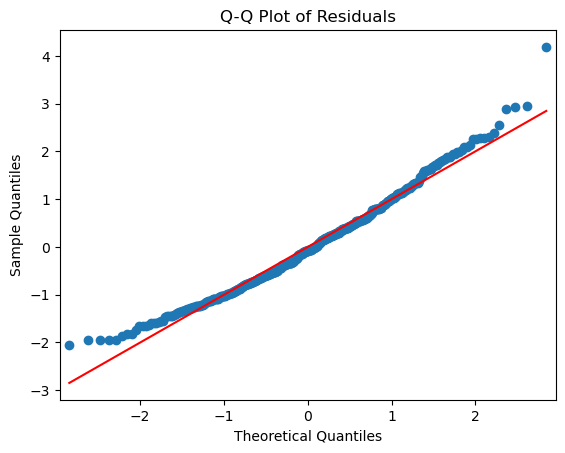

In [8]:
# 2. Check Normality of Residuals with Q-Q plot
sm.qqplot(std_resids['fantasy_points_ppr'], line='s') # Use statsmodels for Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()

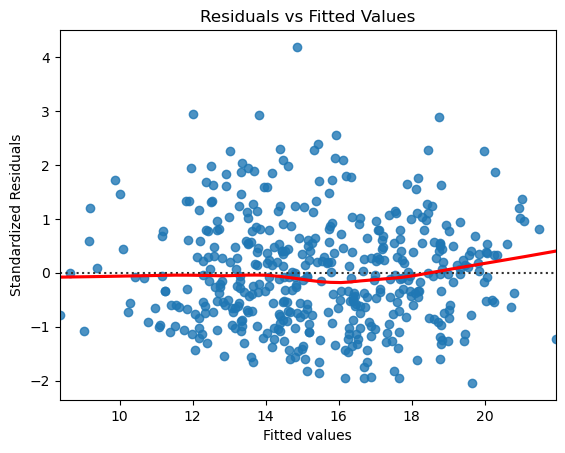

In [9]:
# 3. Check Homoscedasticity/Linearity with Residuals vs. Fitted plot
sns.residplot(x=base_model.predict(base_X), y=std_resids, lowess=True, line_kws={'color':'red'}) # Use seaborn residplot
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.show()

## Cross-Validation

In [10]:
base_scores = cross_val_score(base_model, base_X, y, cv=ps, scoring="neg_root_mean_squared_error")

# Convert negative MSE scores to positive values for easier interpretation as "error"
base_rmse_scores = -base_scores

base_cv_rmse = np.mean(base_rmse_scores)
base_cv_rmse_sd = np.std(base_rmse_scores) / np.sqrt(5)

# Model with Twitter Index

In [11]:
twitter_X = off_df[['prev_twitter_index', 'prev_fantasy_pts', 'opp_defense_dvoa', 'RB', 'TE', 'WR']]
twitter_model = LinearRegression()

## Model Diagnostics

In [12]:
twitter_model.fit(twitter_X, y)
twitter_residuals = y - twitter_model.predict(twitter_X)
twitter_std_resids = (twitter_residuals - np.mean(twitter_residuals)) / np.std(twitter_residuals)

/home/rjy2/anaconda3/envs/sentiment/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


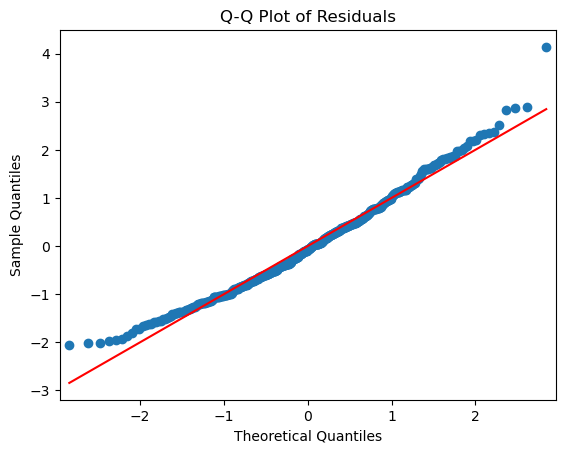

In [13]:
sm.qqplot(twitter_std_resids['fantasy_points_ppr'], line='s') # Use statsmodels for Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()

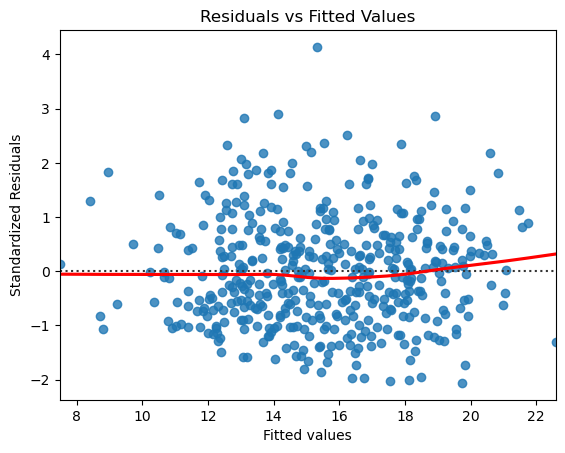

In [14]:
sns.residplot(x=twitter_model.predict(twitter_X), y=twitter_std_resids, lowess=True, line_kws={'color':'red'}) # Use seaborn residplot
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.show()

## Cross-Validation

In [15]:
twitter_scores = cross_val_score(twitter_model, twitter_X, y, cv=ps, scoring="neg_root_mean_squared_error")

# Convert negative MSE scores to positive values for easier interpretation as "error"
twitter_rmse_scores = -twitter_scores

twitter_cv_rmse = np.mean(twitter_rmse_scores)
twitter_cv_rmse_sd = np.std(twitter_rmse_scores) / np.sqrt(5)

# Model with Global Index

In [16]:
global_X = off_df[['prev_global_index', 'prev_fantasy_pts', 'opp_defense_dvoa', 'RB', 'TE', 'WR']]
global_model = LinearRegression()

## Model Diagnostics

In [17]:
global_model.fit(global_X, y)
global_residuals = y - global_model.predict(global_X)
global_std_resids = (global_residuals - np.mean(global_residuals)) / np.std(global_residuals)

/home/rjy2/anaconda3/envs/sentiment/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


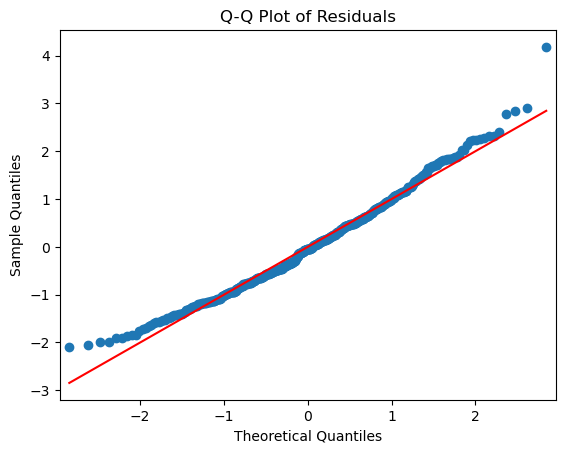

In [18]:
sm.qqplot(global_std_resids['fantasy_points_ppr'], line='s') # Use statsmodels for Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()

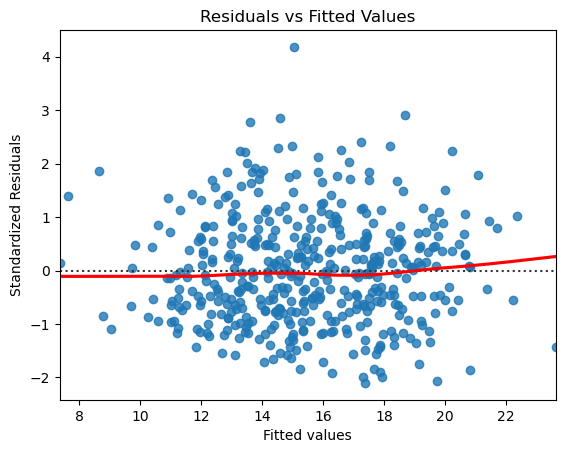

In [19]:
sns.residplot(x=global_model.predict(global_X), y=global_std_resids, lowess=True, line_kws={'color':'red'}) # Use seaborn residplot
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.show()

## Cross-Validation

In [20]:
global_scores = cross_val_score(global_model, global_X, y, cv=ps, scoring="neg_root_mean_squared_error")

# Convert negative MSE scores to positive values for easier interpretation as "error"
global_rmse_scores = -global_scores

global_cv_rmse = np.mean(global_rmse_scores)
global_cv_rmse_sd = np.std(global_rmse_scores) / np.sqrt(5)

## Comparison

In [21]:
cv_rmses = pd.DataFrame({
    'Model': ['Base', 'Twitter', 'Global'],
    'Lower Bound': [base_cv_rmse - base_cv_rmse_sd, twitter_cv_rmse - twitter_cv_rmse_sd, global_cv_rmse - global_cv_rmse_sd],
    'CV RMSE': [base_cv_rmse, twitter_cv_rmse, global_cv_rmse],
    'Upper Bound': [base_cv_rmse + base_cv_rmse_sd, twitter_cv_rmse + twitter_cv_rmse_sd, global_cv_rmse + global_cv_rmse_sd]
})
cv_rmses

,Model,Lower Bound,CV RMSE,Upper Bound
0,Base,8.231727,8.492994,8.754261
1,Twitter,8.228644,8.488403,8.748163
2,Global,8.215854,8.478271,8.740689


## Twitter Partial F-Test

In [22]:
# 1. Fit models: Full (with education) vs Reduced (without education)
full_model = smf.ols('fantasy_points_ppr ~ prev_twitter_index + prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()
reduced_model = smf.ols('fantasy_points_ppr ~ prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()

# 2. Perform F-test
print(anova_lm(reduced_model, full_model))

   df_resid           ssr  df_diff     ss_diff        F    Pr(>F)
0     445.0  31079.529242      0.0         NaN      NaN       NaN
1     444.0  30930.066670      1.0  149.462572  2.14553  0.143693


## Global Index Partial F-Test

In [23]:
# 1. Fit models: Full (with education) vs Reduced (without education)
full_model = smf.ols('fantasy_points_ppr ~ prev_global_index + prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()
reduced_model = smf.ols('fantasy_points_ppr ~ prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()

# 2. Perform F-test
print(anova_lm(reduced_model, full_model))

   df_resid           ssr  df_diff    ss_diff         F   Pr(>F)
0     445.0  31079.529242      0.0        NaN       NaN      NaN
1     444.0  30782.155912      1.0  297.37333  4.289295  0.03893
